# Crypto Trader Behavior Analysis Using Market Sentiment

## Project Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear/Greed Index) and trader performance using historical trading data from Hyperliquid.

The project aims to uncover behavioral patterns, trading performance trends, and actionable insights that can support smarter trading strategies.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Exploratory Data Analysis (EDA)
- Data Visualization

## Loading and Understanding the Datasets

In this step, we load the trader dataset and Bitcoin Fear & Greed Index dataset. We inspect the structure, columns, and missing values to understand the data before analysis.

In [74]:
import pandas as pd

In [75]:
import numpy as np

In [76]:
import matplotlib.pyplot as plt

In [77]:
import seaborn as sns

In [78]:
trader_df = pd.read_csv("historical_data.csv")

sentiment_df = pd.read_csv("fear_greed_index.csv")

In [79]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [80]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [81]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [82]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [83]:
trader_df.shape

(211224, 16)

In [84]:
sentiment_df.shape

(2644, 4)

In [85]:
trader_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [86]:
sentiment_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [87]:
trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [88]:
trader_df['date'] = trader_df['Timestamp IST'].dt.date

In [89]:
sentiment_df['date'] = pd.to_datetime(
    sentiment_df['date']
).dt.date

## Merging the Datasets

The trader dataset was merged with the Bitcoin Fear & Greed Index dataset using the common date column. This allows analysis of trader performance and trading behavior under different market sentiment conditions.

In [90]:
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on='date',
    how='left'
)

In [91]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [92]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')

## Note on Dataset Fields

The assignment description mentioned leverage-related fields in the trader dataset. However, the provided dataset did not contain an explicit leverage column. Therefore, leverage-based analysis was not included in this project.

In [93]:
merged_df.duplicated().sum()

0

## Duplicate Check

No duplicate rows were found in the merged dataset.

In [19]:
merged_df[['classification', 'value']].isnull().sum()

classification    6
value             6
dtype: int64

## Handling Missing Values After Merge

A small number of rows contained missing sentiment values after merging because some trading dates did not have matching Fear & Greed Index data. These rows were removed to ensure clean and reliable sentiment analysis.

In [20]:
merged_df = merged_df.dropna(subset=['classification'])

In [21]:
merged_df[['classification', 'value']].isnull().sum()

classification    0
value             0
dtype: int64

# Exploratory Data Analysis (EDA)

# Sentiment Distribution

# How many Fear vs Greed days exist.

## Market Sentiment Distribution

This visualization shows the distribution of Fear and Greed sentiment classifications in the merged dataset.

In [22]:
merged_df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

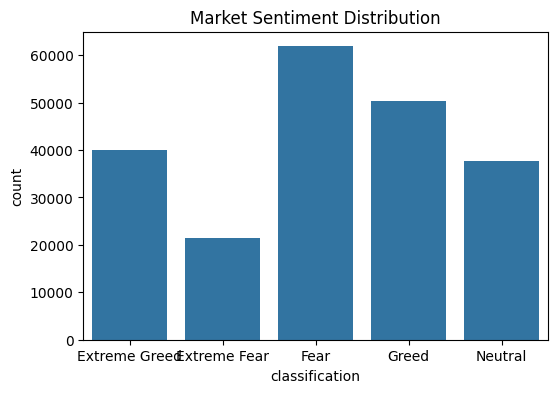

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='classification',
    data=merged_df
)

plt.title('Market Sentiment Distribution')

plt.show()

### Insights

- Fear sentiment had the highest number of trading records, indicating high trading activity during uncertain market conditions.
- Extreme Fear periods were comparatively less frequent.
- A significant number of trades also occurred during Greed and Extreme Greed periods, suggesting strong trader participation during bullish sentiment.

## Profitability Analysis by Market Sentiment

In this section, we analyze the average trader profit and loss (Closed PnL) across different market sentiment conditions to understand how trader performance changes during Fear, Greed, and Neutral markets.

In [24]:
merged_df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

## Understanding Closed PnL

Closed PnL (Profit and Loss) represents the final profit or loss made by a trader after closing a trade.

- Positive values indicate profit
- Negative values indicate loss

This column is important because it helps measure trader performance under different market sentiment conditions such as Fear and Greed.

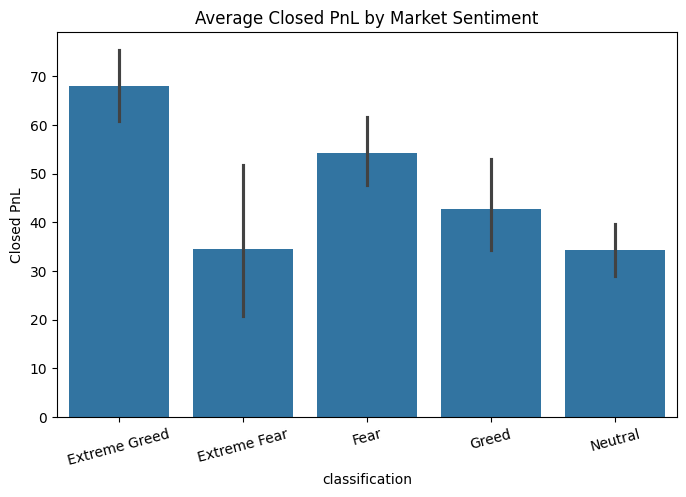

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='Closed PnL',
    data=merged_df
)

plt.title('Average Closed PnL by Market Sentiment')

plt.xticks(rotation=15)

plt.show()

### Key Insights from Profitability Analysis

- Traders achieved the highest average Closed PnL during Extreme Greed market conditions.
- Extreme Fear sentiment showed the lowest average profitability, indicating difficult market conditions for traders.
- Fear sentiment surprisingly showed stronger profitability than normal Greed conditions, suggesting that some traders may benefit from volatile market rebounds.
- Neutral market conditions resulted in comparatively moderate trading performance.

## Most Frequently Traded Cryptocurrencies

In this section, we analyze the most actively traded cryptocurrencies to understand trader preferences and market activity.

In [26]:
top_coins = merged_df['Coin'].value_counts().head(10)

top_coins

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

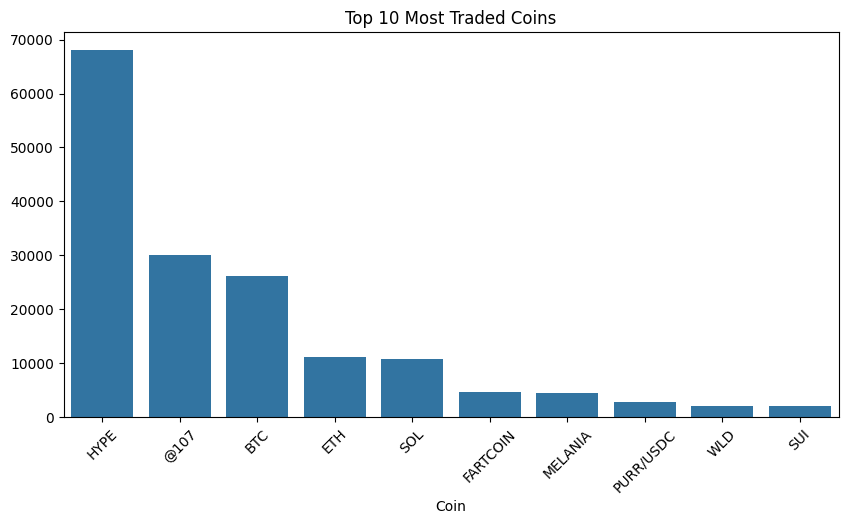

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_coins.index,
    y=top_coins.values
)

plt.title('Top 10 Most Traded Coins')

plt.xticks(rotation=45)

plt.show()

### Key Insights from Coin Trading Activity

- HYPE was the most actively traded cryptocurrency by a large margin, indicating extremely high trader interest and market activity.
- BTC, ETH, and SOL also showed significant trading activity, reflecting their importance in the crypto market.
- Trading activity appears highly concentrated among a few major assets, while smaller coins experienced relatively lower participation.
- High trading frequency in specific assets may indicate increased volatility and speculative trading behavior.

## Buy vs Sell Trading Activity

In this section, we analyze trader buying and selling activity to understand market participation and trading behavior.

In [28]:
merged_df['Side'].value_counts()

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

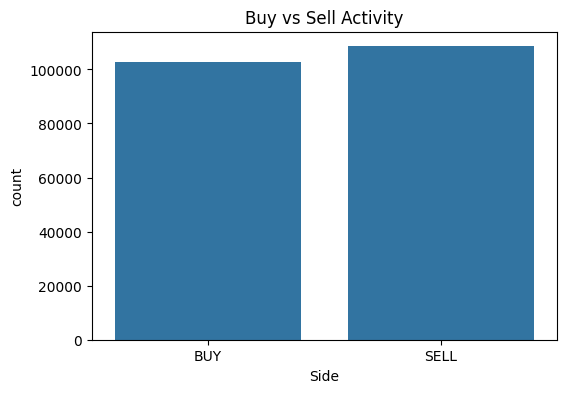

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Side',
    data=merged_df
)

plt.title('Buy vs Sell Activity')

plt.show()

### Key Insights from Buy vs Sell Activity

- Sell trades were slightly higher than buy trades, indicating stronger selling or profit-booking activity in the market.
- The difference between buy and sell activity was relatively small, suggesting balanced market participation.
- The high volume of both buy and sell trades reflects active trading behavior and strong market liquidity.

## Profitability Distribution Across Market Sentiments

This section analyzes how trader profit and loss vary across different market sentiment conditions such as Fear, Greed, and Extreme Greed.

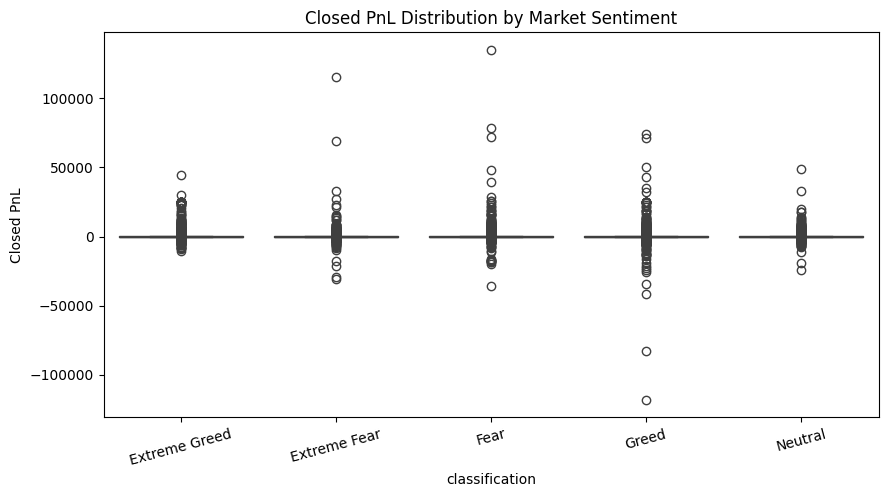

In [30]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged_df
)

plt.title('Closed PnL Distribution by Market Sentiment')

plt.xticks(rotation=15)

plt.show()

### Key Insights from Profitability Distribution

- Fear and Greed market conditions showed high variability in trader profitability, indicating increased market volatility.
- Fear sentiment produced some extremely high profits, suggesting that volatile market rebounds may create profitable opportunities for skilled traders.
- Greed sentiment also showed some of the largest losses, which may indicate excessive risk-taking and overleveraging during bullish market conditions.
- Neutral market conditions displayed comparatively lower volatility and more moderate trading outcomes.
- Overall, market sentiment appears to significantly influence trader performance and trading risk.

## Trading Volume Analysis by Market Sentiment

This section analyzes how trading volume changes across different market sentiment conditions.

In [32]:
merged_df.groupby('classification')['Size USD'].mean() #trade value in US dollars

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

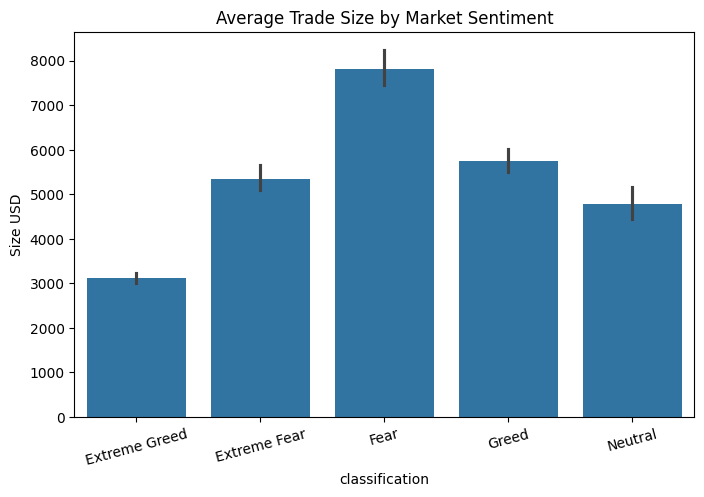

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='Size USD',
    data=merged_df
)

plt.title('Average Trade Size by Market Sentiment')

plt.xticks(rotation=15)

plt.show()

### Key Insights from Trade Size Analysis

- Fear market conditions showed the highest average trade sizes, suggesting that traders may take larger positions during volatile market periods.
- Extreme Greed sentiment showed the lowest average trade size, indicating comparatively cautious trading behavior despite bullish sentiment.
- Greed and Extreme Fear conditions also demonstrated significant trading activity and risk participation.
- Overall, market sentiment appears to influence trader risk appetite and position sizing behavior.

## Transaction Fee Analysis by Market Sentiment

This section analyzes transaction fees across different market sentiment conditions to understand trading activity and market participation intensity.

In [34]:
merged_df.groupby('classification')['Fee'].mean()

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

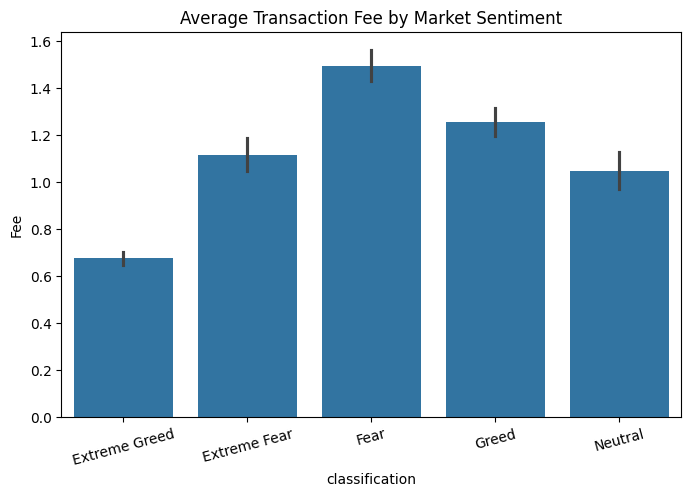

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='Fee',
    data=merged_df
)

plt.title('Average Transaction Fee by Market Sentiment')

plt.xticks(rotation=15)

plt.show()

### Key Insights from Transaction Fee Analysis

- Fear sentiment resulted in the highest average transaction fees, indicating increased trading intensity and larger trade sizes during volatile market conditions.
- Extreme Greed sentiment showed the lowest average fees, suggesting comparatively lower trading aggression and smaller trade sizes.
- The relationship between higher trade sizes and higher transaction fees during Fear conditions indicates increased trader activity and risk-taking behavior.
- Overall, market sentiment appears to significantly influence trading intensity and transaction behavior.

## Correlation Analysis

This section analyzes relationships between important numerical variables such as trade size, profit/loss, leverage-related activity, and transaction fees.

In [36]:
correlation = merged_df[
    ['Execution Price',
     'Size Tokens',
     'Size USD',
     'Closed PnL',
     'Fee']
].corr()

correlation

,Execution Price,Size Tokens,Size USD,Closed PnL,Fee
Execution Price,1.000000,-0.017185,0.189859,-0.006429,0.225266
Size Tokens,-0.017185,1.000000,0.013310,0.005067,0.006710
Size USD,0.189859,0.013310,1.000000,0.123645,0.745940
Closed PnL,-0.006429,0.005067,0.123645,1.000000,0.084094
Fee,0.225266,0.006710,0.745940,0.084094,1.000000


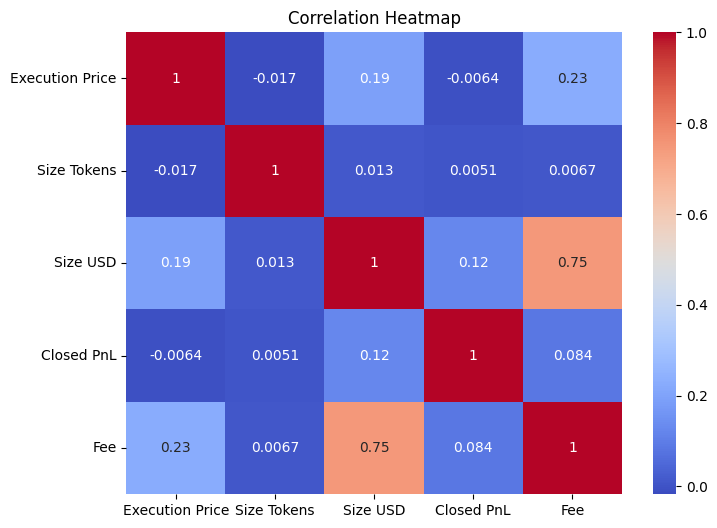

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Key Insights from Correlation Analysis

- Trade size in USD and transaction fees showed a strong positive correlation (0.75), indicating that larger trades generally result in higher transaction fees.
- Trade size and profitability showed only a weak positive relationship, suggesting that larger positions do not always guarantee higher profits.
- Most variables showed weak correlations with Closed PnL, indicating that trader profitability may depend on multiple market factors rather than a single variable.
- Overall, the correlation analysis highlights the complex nature of trading performance and market behavior.

## Daily Profit and Loss Per Trader

This section calculates the daily profit and loss (PnL) generated by each trader account to analyze trader performance over time.

In [39]:
daily_pnl = merged_df.groupby(
    ['date', 'Account']
)['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


### Understanding Daily PnL Per Trader

The daily PnL table represents the total profit or loss generated by each trader account on a given day.

- Positive values indicate profitable trading days
- Negative values indicate losing trading days
- Zero values indicate neutral outcomes or balanced trades

This analysis helps evaluate trader consistency and overall trading performance.

## Top Profitable Traders

This section identifies the top-performing trader accounts based on total cumulative profit and loss.

In [40]:
top_traders = merged_df.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64

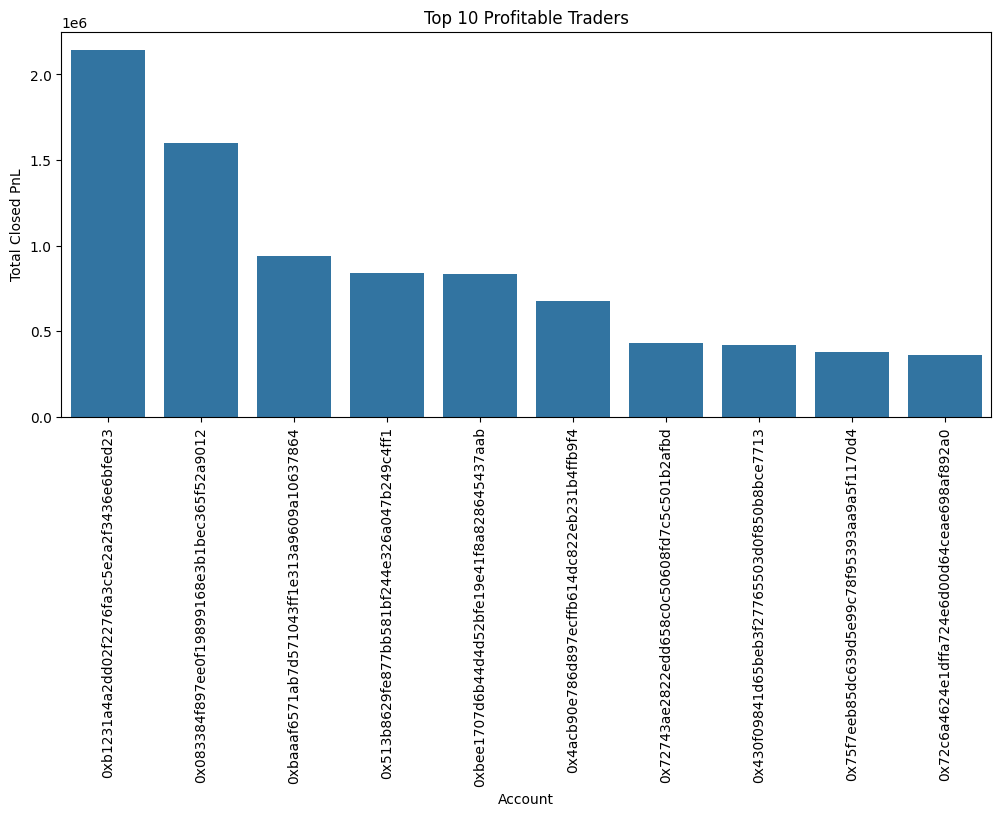

In [41]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_traders.index,
    y=top_traders.values
)

plt.title('Top 10 Profitable Traders')

plt.ylabel('Total Closed PnL')

plt.xticks(rotation=90)

plt.show()

### Key Insights from Top Trader Analysis

- A small number of traders generated exceptionally high profits, indicating strong concentration of profitability among top-performing accounts.
- The top trader significantly outperformed the remaining traders, suggesting differences in trading strategy, experience, or risk management.
- Profitability declines gradually across lower-ranked traders, highlighting variability in trader performance and consistency.
- The results support the existence of distinct trader segments, including highly profitable traders and average-performing participants.

## Win Rate Analysis

Win rate measures the percentage of profitable trades and helps evaluate trader consistency and performance.

In [42]:
merged_df['Winning Trade'] = merged_df['Closed PnL'] > 0

In [43]:
win_rate = merged_df.groupby(
    'classification'
)['Winning Trade'].mean() * 100

win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Winning Trade, dtype: float64

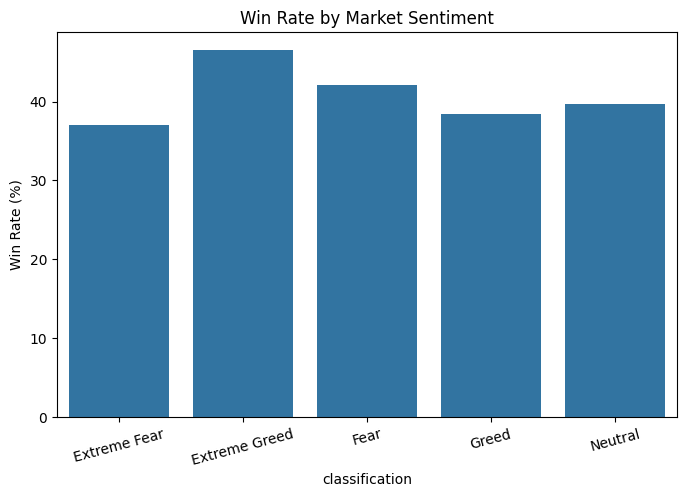

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

plt.title('Win Rate by Market Sentiment')

plt.ylabel('Win Rate (%)')

plt.xticks(rotation=15)

plt.show()

### Key Insights from Win Rate Analysis

- Extreme Greed market conditions produced the highest trader win rate, indicating improved trader performance during strong bullish sentiment.
- Extreme Fear conditions showed the lowest win rate, suggesting that highly uncertain markets negatively impact trading success.
- Fear sentiment demonstrated a higher win rate than normal Greed conditions, possibly due to profitable rebound opportunities during volatile markets.
- Neutral sentiment showed relatively balanced trading outcomes with moderate profitability levels.
- Overall, market sentiment appears to significantly influence trader success rates and trading performance.

## Long vs Short Trading Analysis

This section analyzes trader directional bias by comparing long and short trading activity under different market sentiment conditions.

In [46]:
merged_df['Direction'].unique()

array(['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion',
       'Open Short', 'Close Short', 'Long > Short', 'Short > Long',
       'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement'],
      dtype=object)

In [47]:
long_short_df = merged_df[
    merged_df['Direction'].isin(
        ['Open Long', 'Open Short']
    )
]

In [48]:
long_short_counts = long_short_df['Direction'].value_counts()

long_short_counts

Direction
Open Long     49895
Open Short    39741
Name: count, dtype: int64

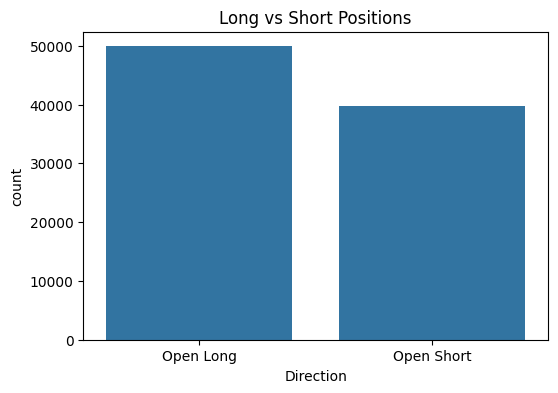

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Direction',
    data=long_short_df
)

plt.title('Long vs Short Positions')

plt.show()

### Key Insights from Long vs Short Analysis

- Traders opened more long positions than short positions, indicating an overall bullish market bias.
- The large number of short positions also suggests active participation in bearish trading strategies and two-sided market activity.
- The relatively balanced distribution between long and short positions reflects high speculative participation in the crypto market.
- Overall, trader directional behavior appears strongly influenced by market sentiment and volatility conditions.

## Trader Segmentation: Frequent vs Infrequent Traders

This section segments traders based on trading frequency to identify highly active and less active market participants.

In [50]:
trade_counts = merged_df.groupby(
    'Account'
).size()

In [51]:
frequent_traders = trade_counts[
    trade_counts > trade_counts.median()
]

infrequent_traders = trade_counts[
    trade_counts <= trade_counts.median()
]

In [52]:
print("Frequent Traders:", len(frequent_traders))

print("Infrequent Traders:", len(infrequent_traders))

Frequent Traders: 16
Infrequent Traders: 16


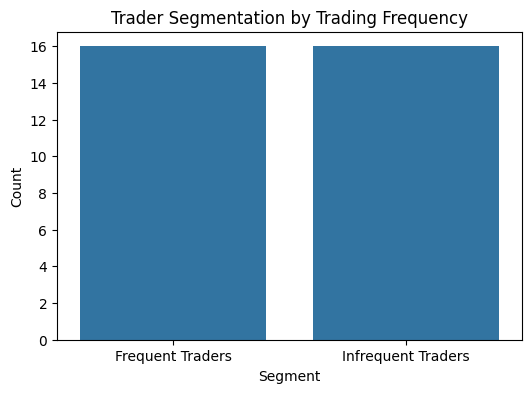

In [53]:
segment_counts = pd.DataFrame({
    'Segment': ['Frequent Traders', 'Infrequent Traders'],
    'Count': [len(frequent_traders), len(infrequent_traders)]
})

plt.figure(figsize=(6,4))

sns.barplot(
    x='Segment',
    y='Count',
    data=segment_counts
)

plt.title('Trader Segmentation by Trading Frequency')

plt.show()

### Key Insights from Trader Frequency Segmentation

- Traders were divided into frequent and infrequent groups based on median trading activity.
- Frequent traders represent highly active market participants who execute trades more regularly.
- Infrequent traders participate less actively and may follow more selective trading strategies.
- Segmenting traders by activity level helps identify differences in trading behavior and market engagement.

## Trader Segmentation: Consistent Winners vs Other Traders

This section segments traders based on cumulative profitability to identify consistently profitable traders and lower-performing participants.

In [54]:
trader_pnl = merged_df.groupby(
    'Account'
)['Closed PnL'].sum()

In [55]:
consistent_winners = trader_pnl[
    trader_pnl > 0
]

other_traders = trader_pnl[
    trader_pnl <= 0
]

In [56]:
print("Consistent Winners:", len(consistent_winners))

print("Other Traders:", len(other_traders))

Consistent Winners: 29
Other Traders: 3


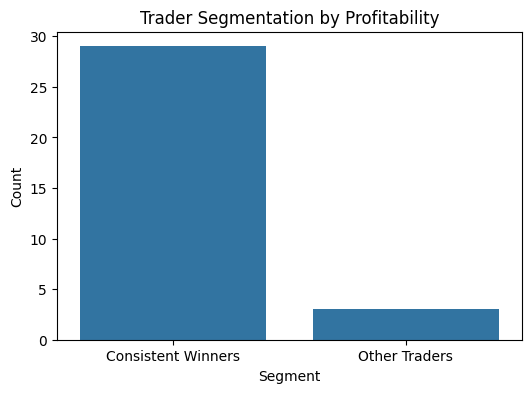

In [57]:
winner_segments = pd.DataFrame({
    'Segment': ['Consistent Winners', 'Other Traders'],
    'Count': [len(consistent_winners), len(other_traders)]
})

plt.figure(figsize=(6,4))

sns.barplot(
    x='Segment',
    y='Count',
    data=winner_segments
)

plt.title('Trader Segmentation by Profitability')

plt.show()

### Key Insights from Profitability Segmentation

- Traders were segmented based on cumulative profitability into consistent winners and lower-performing traders.
- Consistent winners represent traders who achieved overall positive trading performance.
- The presence of lower-performing traders highlights the high-risk and volatile nature of crypto trading markets.
- Profitability segmentation helps identify behavioral differences and performance variability among traders.

# Strategy Recommendations

## Strategy 1: Risk-Controlled Trading During Fear Markets

The analysis showed that Fear market conditions generated the highest average trade sizes and transaction fees, indicating aggressive trading behavior and increased market volatility.

Recommendation:
- Traders should apply stricter risk management during Fear periods.
- Lower leverage and controlled position sizing may help reduce exposure to sudden market movements.
- Experienced traders may still benefit from volatility-driven opportunities, but disciplined risk management is essential.

## Strategy 2: Momentum-Based Trading During Extreme Greed

The analysis showed that Extreme Greed conditions produced the highest average profitability and win rates for traders.

Recommendation:
- Traders may consider momentum-following strategies during strong bullish sentiment periods.
- Higher win rates during Extreme Greed suggest favorable market conditions for trend-following strategies.
- However, traders should still monitor for overconfidence and sudden reversals because Greed conditions also showed large loss distributions.

## Strategy 3: Segment-Based Trading Approaches

The analysis identified significant differences between trader groups, including frequent traders, consistent winners, and lower-performing participants.

Recommendation:
- Frequent traders should focus on disciplined execution and transaction cost management because higher trading activity increases fees and risk exposure.
- Less experienced or inconsistent traders may benefit from lower-frequency strategies and smaller position sizes during highly volatile market conditions.
- Segment-specific trading approaches can improve overall portfolio stability and risk-adjusted performance.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader behavior using historical trading data and the Fear & Greed Index.

The analysis revealed that market sentiment significantly influences trader profitability, trading activity, risk appetite, and directional behavior. Fear conditions were associated with larger trade sizes and higher transaction fees, while Extreme Greed conditions produced the highest win rates and profitability.

The project also identified distinct trader segments, including frequent traders and consistently profitable traders, highlighting variability in trading behavior and performance.

Overall, the findings demonstrate how sentiment-driven analytics can support smarter trading strategies, improved risk management, and better understanding of market psychology.

# Bonus Section: Predictive Modeling

This section builds a simple machine learning model to predict whether a trade will be profitable based on market sentiment and trading behavior features.

# Creating Target variable

In [94]:
merged_df['Profitability'] = (
    merged_df['Closed PnL'] > 0
).astype(int)

# Selecting Features

In [95]:
features = merged_df[
    ['classification',
     'Size USD',
     'Fee',
     'Side',
     'Direction']
]

# Target Variable

In [96]:
target = merged_df['Profitability']

# ENCODE CATEGORICAL COLUMNS

In [97]:
from sklearn.preprocessing import LabelEncoder

In [99]:
#cerating encoder
encoder = LabelEncoder()



In [101]:
#encoding columns
for col in ['classification', 'Side', 'Direction']:
    features[col] = encoder.fit_transform(features[col])

C:\Users\pc\AppData\Local\Temp\ipykernel_12644\3697393840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[col] = encoder.fit_transform(features[col])
C:\Users\pc\AppData\Local\Temp\ipykernel_12644\3697393840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[col] = encoder.fit_transform(features[col])
C:\Users\pc\AppData\Local\Temp\ipykernel_12644\3697393840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

# Train and Test Split

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [104]:
#train model
from sklearn.ensemble import RandomForestClassifier

In [105]:
model = RandomForestClassifier(
    random_state=42
)

In [106]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
predictions = model.predict(X_test)

In [108]:
from sklearn.metrics import accuracy_score

In [109]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9222393182625163


## Predictive Model Performance

The Random Forest classification model achieved an accuracy of approximately 92%, indicating strong predictive capability in identifying profitable and non-profitable trades using sentiment and behavioral trading features.

The results demonstrate that market sentiment, trade size, transaction fees, and trading direction contain meaningful information related to trading profitability.

## Feature Importance Analysis

This section identifies which features contributed most to the predictive model's profitability predictions.

In [110]:
importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,Direction,0.629355
2,Fee,0.156040
1,Size USD,0.143126
3,Side,0.054135
0,classification,0.017345


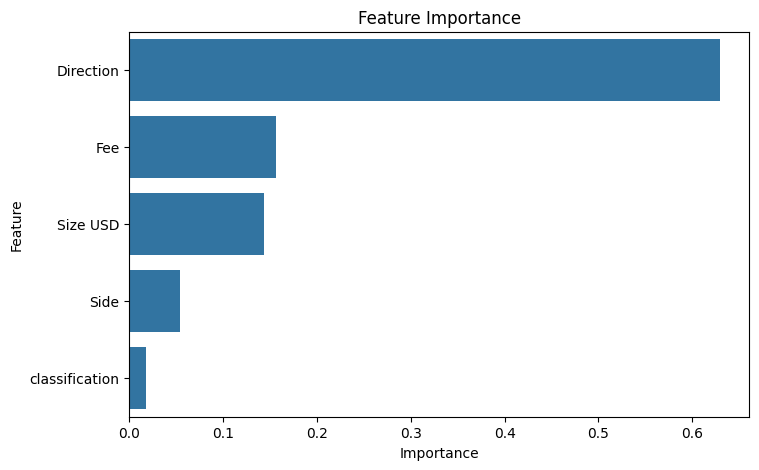

In [111]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

### Key Insights from Feature Importance Analysis

- Trading direction was the most influential feature in predicting trade profitability, indicating that trader positioning behavior strongly impacts outcomes.
- Transaction fees and trade size also contributed significantly to model predictions, suggesting that trading intensity and position sizing affect profitability.
- Market sentiment classification showed comparatively lower direct importance, indicating that trader behavior may play a stronger role than sentiment labels alone.
- The results demonstrate that behavioral trading features contain meaningful predictive information for profitability analysis.